# NOVAPAY

### Import Libraries

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [300]:
# Load data
df_raw = pd.read_csv("/home/whizic/UK/AMDARI/NOVAPAY/nova_pay_combined.csv")
df = df_raw.copy()
df.shape

(11400, 26)

In [301]:
df.head(5)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [302]:
# Check for missing values
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [303]:
# check for data types
df.dtypes

transaction_id                object
customer_id                   object
timestamp                     object
home_country                  object
source_currency               object
dest_currency                 object
channel                       object
amount_src                    object
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                     object
new_device                      bool
ip_address                    object
ip_country                    object
location_mismatch               bool
ip_risk_score                float64
kyc_tier                      object
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [304]:
# examine the distribution of the target variable
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.912544
1    0.087456
Name: proportion, dtype: float64

### Data Cleaning

In [305]:
# convert timestamp to datetime, coercing invalid values to NaT (Not a Time)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [306]:
# convert amouunt_src to numeric float, setting non-numeric values to NaN
df['amount_src'] = (
    df['amount_src']
      .astype(str)
      .str.replace(',', '', regex=False)
      .str.strip()
)
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')

In [307]:
# amount in source currency have no missing values, but amount in USD has missing values. This could be a conversion(exchange) rate issue.
# calculate exchange rate per currency
# select only the rows where amount_usd is not null
# group by source_currency
# calculate the mean exchange rate for each source_currency
# convert the result to a dictionary for easy lookup
exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(lambda x: (x['amount_usd'] / x['amount_src']).mean()).to_dict()

/tmp/ipykernel_113772/433929445.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(lambda x: (x['amount_usd'] / x['amount_src']).mean()).to_dict()


In [308]:
# display the exchange rates for each source currency
exchange_rates

{'CAD': 0.7216095926871465,
 'GBP': 1.2234540399539093,
 'USD': 0.9838792221084954}

In [309]:
# check for all source currencies in the dataset
df['source_currency'].value_counts()

source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [310]:
# fill in missing amount_usd values using the calculated exchange rates
# if amount_usd is already present, keep it; 
# if not, calculate it using amount_src multiplied by the exchange rate for the corresponding source_currency
# default to 1 if the currency is not found in the exchange_rates dictionary
df['amount_usd'] = df.apply(
  lambda row: row['amount_usd'] if pd.notna(row['amount_usd']) else row['amount_src'] * exchange_rates.get(row['source_currency'], 1), axis=1) 

In [311]:
# fill missing values for fee using the median of the channel
# then fill any remaining missing values with the overall median
df['fee'] = df.groupby('channel')['fee'].transform(lambda x: x.fillna(x.median()))

In [312]:
# fill missing ip_country with the equivalent home_country
if {'ip_country', 'home_country'}.issubset(df.columns):
    df['ip_country'] = df['ip_country'].fillna(df['home_country'])


In [313]:
# fill missing data for kyc_tier using the mode
if 'kyc_tier' in df.columns:
    mode_kyc_tier = df['kyc_tier'].mode().iloc[0] if not df['kyc_tier'].mode().empty else "standard"  # default to "standard" if mode is empty
    df['kyc_tier'] = df['kyc_tier'].fillna(mode_kyc_tier)

In [314]:
# fill missing value for device_trust_score
# if device_trust_score and kyc_tier are present, fill missing score per group using the group median 
# fill any remaining missing values with the overall median
if 'device_trust_score' in df.columns and 'kyc_tier' in df.columns:
    df['device_trust_score'] = df.groupby('kyc_tier')['device_trust_score'].transform(lambda x: x.fillna(x.median()))
    df['device_trust_score'] = df['device_trust_score'].fillna(df['device_trust_score'].median())

/home/whizic/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/whizic/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [315]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     61
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [316]:
df.dropna(inplace=True)

In [317]:
df.shape

(11034, 26)

In [318]:
### Sanity Checks
df.describe(include='all')

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11034,11034,11034,11034,11034,11034,11034,11034.000000,11034.000000,11034.000000,...,11034.000000,11034,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000
unique,10840,1314,NaN,7,3,9,12,NaN,NaN,NaN,...,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,7e762adf-98c5-48e5-900a-b6afee5ade30,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,NGN,mobile,NaN,NaN,NaN,...,NaN,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1458,NaN,7687,7773,1426,6136,NaN,NaN,NaN,...,NaN,7885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2024-05-03 12:57:12.877111296+00:00,NaN,NaN,NaN,NaN,440.498887,451.585603,98.186659,...,0.397754,NaN,392.967917,0.654239,0.050027,0.268048,0.469730,0.739804,0.045556,0.089451
min,NaN,NaN,2022-10-03 18:40:59.468549+00:00,NaN,NaN,NaN,NaN,-9997.160000,7.230000,-1.000000,...,0.004000,NaN,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2023-08-15 04:32:57.718548992+00:00,NaN,NaN,NaN,NaN,90.895000,92.570000,2.382500,...,0.209000,NaN,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,2024-05-09 05:02:37.968549120+00:00,NaN,NaN,NaN,NaN,159.120000,163.645000,3.510000,...,0.325000,NaN,286.500000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,2025-01-29 13:30:40.468549120+00:00,NaN,NaN,NaN,NaN,295.147500,302.447500,5.550000,...,0.488000,NaN,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,NaN,NaN,2025-12-16 00:13:41.468549+00:00,NaN,NaN,NaN,NaN,11942.890000,12498.570000,9999.990000,...,1.200000,NaN,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [319]:
# count negative values in key numeric columns
numeric_columns = ['amount_src', 'amount_usd', 'fee', 'device_trust_score', 'txn_velocity_1h', 'txn_velocity_24h', 'risk_score_internal']
negative_values_count = {col: (df[col] < 0).sum() for col in numeric_columns}
negative_values_count

{'amount_src': np.int64(100),
 'amount_usd': np.int64(0),
 'fee': np.int64(94),
 'device_trust_score': np.int64(194),
 'txn_velocity_1h': np.int64(194),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [320]:
# keep only values greater than or equal to zero for the key numeric columns
for col in numeric_columns:
    df = df[df[col] >= 0]

In [321]:
# check for correlation between amount_usd and amount_src
(df["amount_usd"]/df["amount_src"]).describe()

count    10840.000000
mean         1.018123
std          0.136521
min          0.739788
25%          1.000000
50%          1.000000
75%          1.000000
max          1.250405
dtype: float64

In [322]:
# check for future timestamps in the dataset
df[df['timestamp'] > pd.Timestamp.utcnow()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [323]:
# check for location mismatch
df['location_mismatch'].value_counts()

location_mismatch
False    9047
True     1793
Name: count, dtype: int64

In [324]:
# check for unique value counts in categorical columns
categorical_columns = ['home_country', 'source_currency', 'channel', 'dest_currency', 'kyc_tier'] 
unique_value_counts = {col: df[col].unique() for col in categorical_columns}
unique_value_counts

{'home_country': array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
       dtype=object),
 'source_currency': array(['USD', 'CAD', 'GBP'], dtype=object),
 'channel': array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'unknown',
        'mobille', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object),
 'dest_currency': array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
       dtype=object),
 'kyc_tier': array(['standard', 'enhanced', 'low', ' standard  ', 'standrd',
        ' enhanced  ', 'STANDARD', 'unknown', 'enhancd', ' low  ',
        'ENHANCED', 'LOW'], dtype=object)}

In [325]:
# resolve the spacing in home_country and replace unknown with np.nan
df['home_country'] = df['home_country'].str.strip()

In [326]:
# resolve case sensitivity in channel, spelling errors and unknown values
df['channel'] = df['channel'].str.strip().str.lower()
df['channel'] = df['channel'].replace({'unknown': np.nan, 'weeb': 'web', 'mobille': 'mobile'})


In [327]:
# resolve case sensitivity in kyc_tier and replace unknown with np.nan, and spelling errors
df['kyc_tier'] = df['kyc_tier'].str.strip().str.lower()
df['kyc_tier'] = df['kyc_tier'].replace({'unknown': np.nan, 'standrd': 'standard', 'enhancd': 'enhanced'})

In [328]:
# check for missing values
df.isnull().sum()

transaction_id                0
customer_id                   0
timestamp                     0
home_country                  0
source_currency               0
dest_currency                 0
channel                      36
amount_src                    0
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_address                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                     29
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
dtype: int64

In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             10840 non-null  object             
 1   customer_id                10840 non-null  object             
 2   timestamp                  10840 non-null  datetime64[ns, UTC]
 3   home_country               10840 non-null  object             
 4   source_currency            10840 non-null  object             
 5   dest_currency              10840 non-null  object             
 6   channel                    10804 non-null  object             
 7   amount_src                 10840 non-null  float64            
 8   amount_usd                 10840 non-null  float64            
 9   fee                        10840 non-null  float64            
 10  exchange_rate_src_to_dest  10840 non-null  float64            
 11  device_

In [330]:
# drop any remaining rows with missing values
df.dropna(inplace=True)

### Exploratory Data Analysis and Feature Engineering

In [331]:
# explore correlation between numeric features and the target variable
df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

is_fraud                     1.000000
txn_velocity_24h             0.759866
txn_velocity_1h              0.698681
risk_score_internal          0.612653
ip_risk_score                0.591583
chargeback_history_count     0.585117
location_mismatch            0.428793
new_device                   0.389261
corridor_risk                0.198449
exchange_rate_src_to_dest    0.154757
amount_usd                   0.131411
amount_src                   0.130744
fee                          0.130538
account_age_days            -0.291430
device_trust_score          -0.440364
Name: is_fraud, dtype: float64

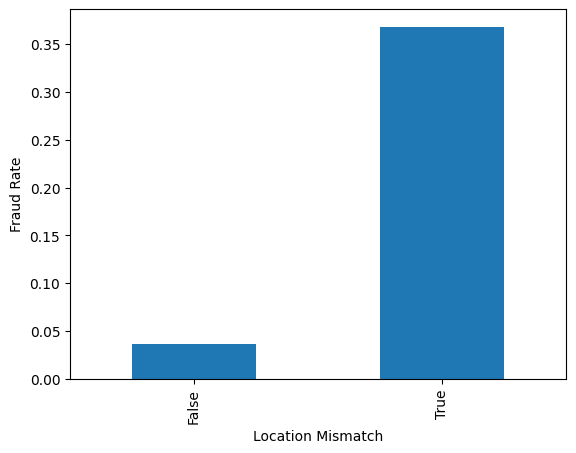

In [332]:

# examine location mismatch with respect to the target variable
df.groupby('location_mismatch')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Location Mismatch')
plt.show()

In [333]:
# explore correlation between categorical features and the target variable
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols

Index(['transaction_id', 'customer_id', 'home_country', 'source_currency',
       'dest_currency', 'channel', 'device_id', 'ip_address', 'ip_country',
       'kyc_tier'],
      dtype='object')

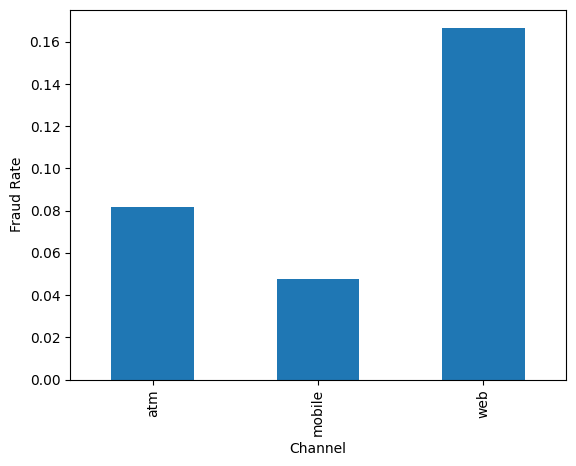

In [334]:
# explore correleation between channel and the target variable
df.groupby('channel')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Channel')
plt.show()

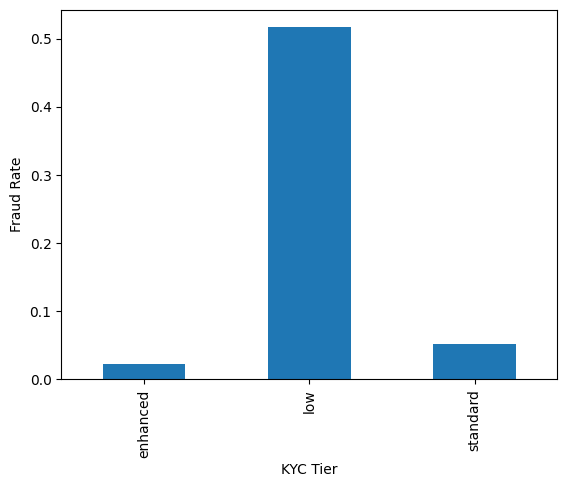

In [335]:
# explore correlation between kyc_tier and the target variable
df.groupby('kyc_tier')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('KYC Tier')
plt.show()

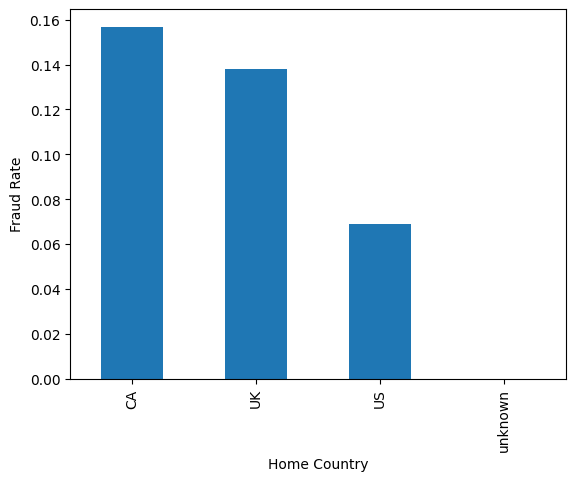

In [336]:
# explore correlation between home_country and the target variable
df.groupby('home_country')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Home Country')
plt.show()

### Feature Engineering

In [337]:
# display timestamp format
df['timestamp'].unique()

<DatetimeArray>
['2022-10-03 18:40:59.468549+00:00', '2022-10-03 20:39:38.468549+00:00',
 '2022-10-03 23:02:43.468549+00:00', '2022-10-04 01:08:53.468549+00:00',
 '2022-10-04 09:35:03.468549+00:00', '2022-10-04 12:09:59.468549+00:00',
 '2022-10-04 12:37:41.468549+00:00', '2022-10-04 16:27:44.468549+00:00',
 '2022-10-04 21:00:36.468549+00:00', '2022-10-04 21:20:42.468549+00:00',
 ...
 '2025-11-24 13:42:17.573611+00:00', '2025-11-25 00:45:10.573611+00:00',
 '2025-11-25 07:44:29.573611+00:00', '2025-11-25 07:56:54.573611+00:00',
 '2025-11-25 09:48:28.573611+00:00', '2025-11-25 10:05:35.573611+00:00',
 '2025-11-26 07:09:56.573611+00:00', '2025-11-27 06:19:11.573611+00:00',
 '2025-11-28 00:53:28.573611+00:00', '2025-11-29 20:10:47.573611+00:00']
Length: 10590, dtype: datetime64[ns, UTC]

In [344]:
# from timestamp, extract the hour of the day, day of the week, and weekend indicator
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("Timestamp Features:")
print(df[['timestamp', 'hour_of_day', 'day_of_week', 'is_weekend']].head())
print("\nHour of Day Distribution:")
print(df['hour_of_day'].value_counts())

Timestamp Features:
                         timestamp  hour_of_day  day_of_week  is_weekend
0 2022-10-03 18:40:59.468549+00:00           18            0           0
1 2022-10-03 20:39:38.468549+00:00           20            0           0
2 2022-10-03 23:02:43.468549+00:00           23            0           0
3 2022-10-04 01:08:53.468549+00:00            1            1           0
4 2022-10-04 09:35:03.468549+00:00            9            1           0

Hour of Day Distribution:
hour_of_day
4     503
19    491
3     480
23    477
8     471
5     471
15    467
18    467
6     464
16    461
0     452
22    450
12    447
10    444
13    444
7     439
20    434
9     425
11    424
21    423
17    422
14    413
2     413
1     398
Name: count, dtype: int64



Hourly Fraud Rate:


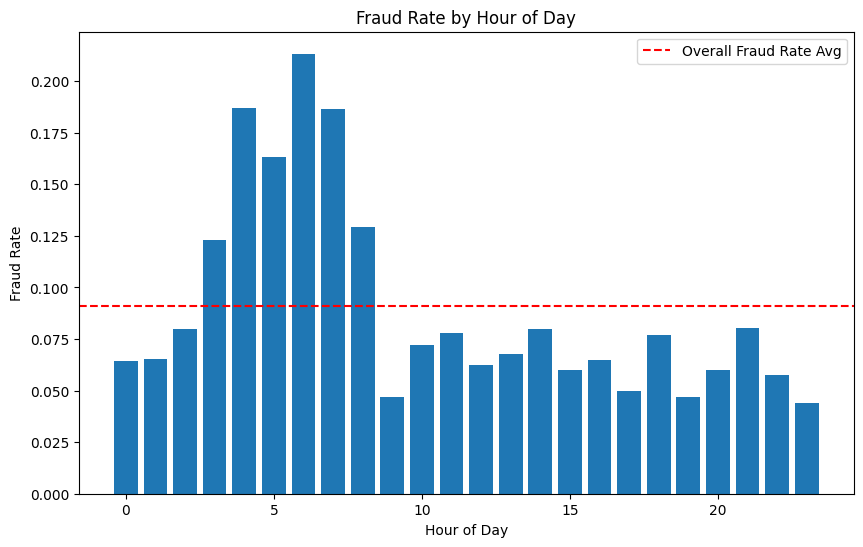

In [348]:
# examine hour and target variable relationship
hourly_fraud_rate = df.groupby('hour_of_day')['is_fraud'].mean()
print("\nHourly Fraud Rate:")

plt.figure(figsize=(10, 6))
plt.bar(hourly_fraud_rate.index, hourly_fraud_rate.values)
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()


Daily Fraud Rate:


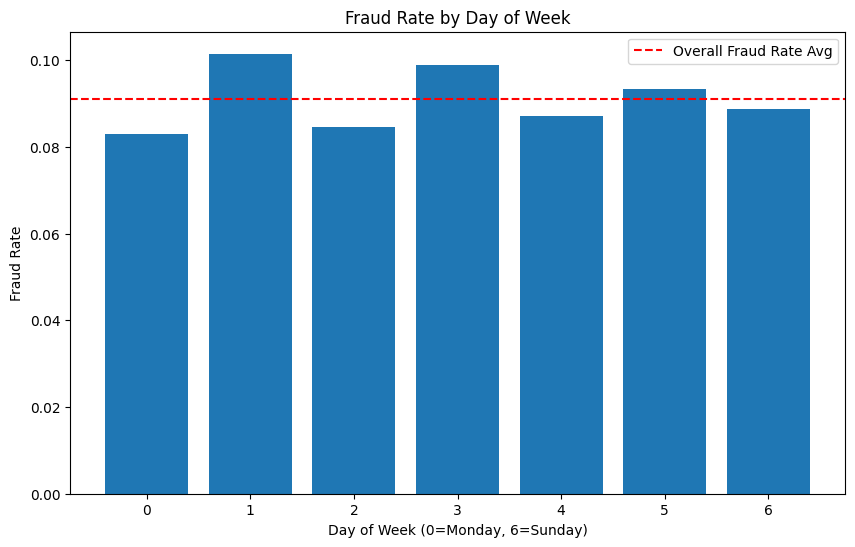

In [349]:
# examnine day of week and target variable relationship
daily_fraud_rate = df.groupby('day_of_week')['is_fraud'].mean()
print("\nDaily Fraud Rate:")
plt.figure(figsize=(10, 6))
plt.bar(daily_fraud_rate.index, daily_fraud_rate.values)
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

/tmp/ipykernel_113772/3563885290.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()


Fraud Rate by Account Age Bucket:
age_bucket
0-30d            NaN
31-90d           NaN
91-180d          NaN
181-365d    0.165064
365+        0.081305
Name: is_fraud, dtype: float64


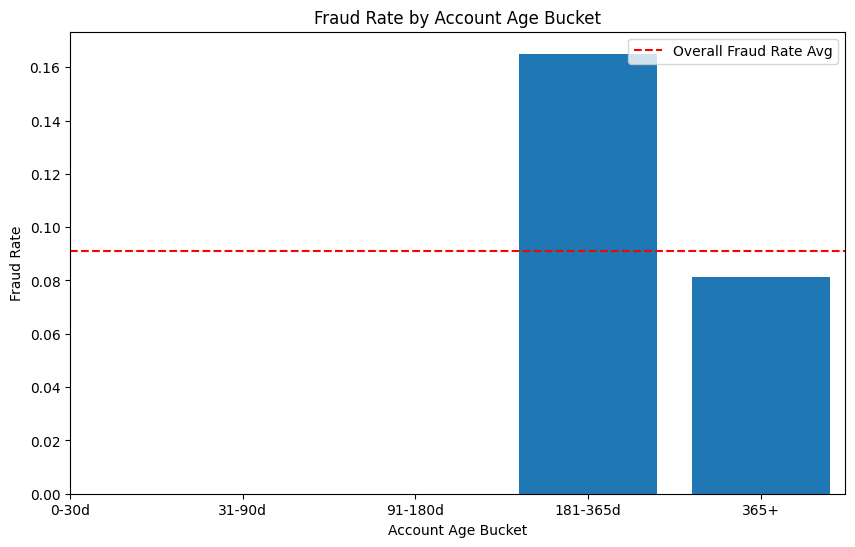

In [360]:
# examine account age and target variable relationship
df['age_bucket'] = pd.cut(df['account_age_days'], bins=[0, 30, 90, 180, 365, 2000], labels=['0-30d', '31-90d', '91-180d', '181-365d', '365+'])

fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()
print("Fraud Rate by Account Age Bucket:")
print(fraud_by_age)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_age)), fraud_by_age.values)
plt.xticks(range(len(fraud_by_age)), fraud_by_age.index)
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Account Age Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

In [362]:
df['account_age_days'].describe()

count    10780.000000
mean       775.922171
std        315.472442
min        185.000000
25%        505.000000
50%        770.000000
75%       1038.000000
max       1354.000000
Name: account_age_days, dtype: float64

Fraud Rate by Transaction Velocity (1h):
txn_velocity_1h
0    0.017459
1    0.000000
2    0.000000
3    0.835878
4    0.842324
5    0.801047
6    0.700000
7    0.702703
8    0.482759
Name: is_fraud, dtype: float64


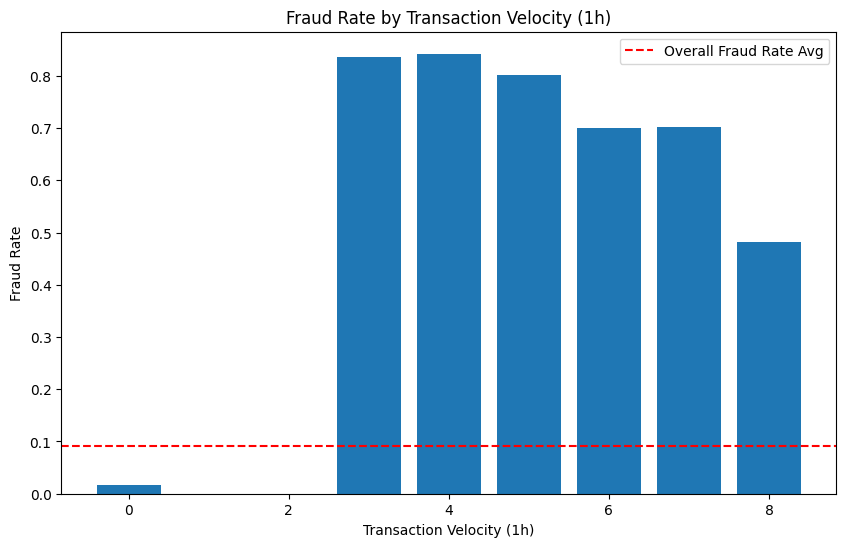

In [365]:
# examine velocity rate and target variable relationship
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean()
print("Fraud Rate by Transaction Velocity (1h):")
print(fraud_by_velocity)

plt.figure(figsize=(10, 6))
plt.bar(fraud_by_velocity.index, fraud_by_velocity.values)
plt.xlabel('Transaction Velocity (1h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (1h)')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

/tmp/ipykernel_113772/2343236712.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amount = df.groupby('amount_usd_bucket')['is_fraud'].mean()


Fraud Rate by Amount USD Bucket:
amount_usd_bucket
0-10          0.000000
11-50         0.020859
51-100        0.016887
101-500       0.061642
501-1000      0.301768
1001-5000     0.744318
5001-10000    0.136842
10001+        0.166667
Name: is_fraud, dtype: float64


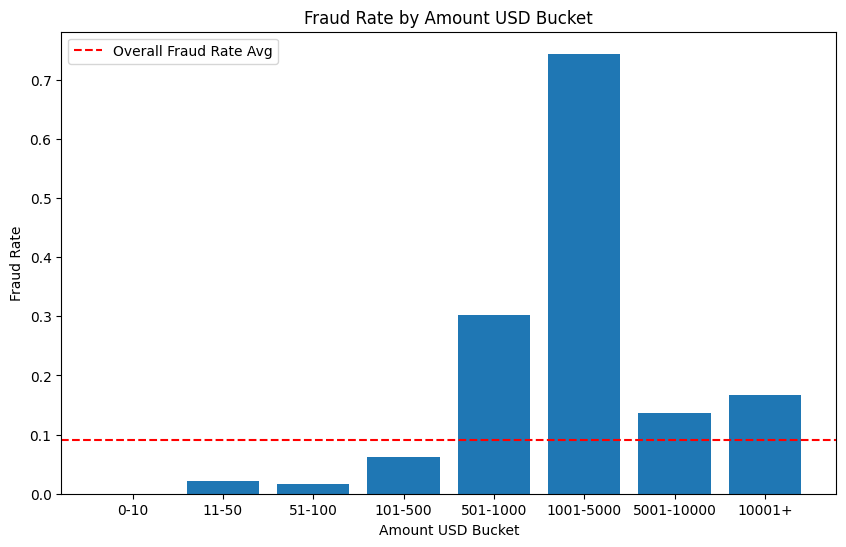

In [366]:
# examine amount_usd and target variable relationship
df['amount_usd_bucket'] = pd.cut(df['amount_usd'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, np.inf], labels=['0-10', '11-50', '51-100', '101-500', '501-1000', '1001-5000', '5001-10000', '10001+'])

fraud_by_amount = df.groupby('amount_usd_bucket')['is_fraud'].mean()
print("Fraud Rate by Amount USD Bucket:")
print(fraud_by_amount)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_amount)), fraud_by_amount.values)
plt.xticks(range(len(fraud_by_amount)), fraud_by_amount.index)
plt.xlabel('Amount USD Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Amount USD Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

/tmp/ipykernel_113772/3197976394.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_risk_score = df.groupby('risk_score_internal_bucket')['is_fraud'].mean()


Fraud Rate by Risk Score Internal Bucket:
risk_score_internal_bucket
0-0.2      0.011902
0.2-0.4    0.037893
0.4-0.6    0.219802
0.6-0.8    1.000000
0.8-1.0    1.000000
Name: is_fraud, dtype: float64


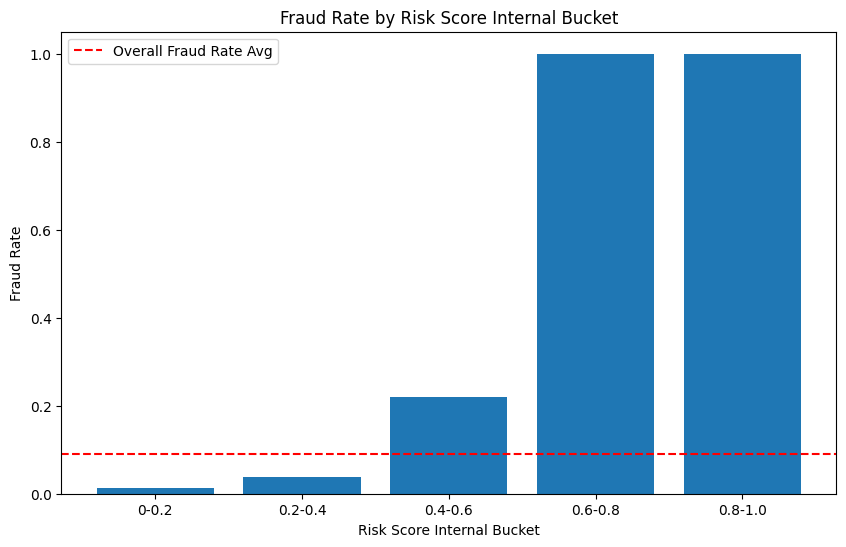

In [367]:
# examine ip risk score and target variable relationship
df['risk_score_internal_bucket'] = pd.cut(df['risk_score_internal'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

fraud_by_risk_score = df.groupby('risk_score_internal_bucket')['is_fraud'].mean()
print("Fraud Rate by Risk Score Internal Bucket:")
print(fraud_by_risk_score)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_risk_score)), fraud_by_risk_score.values)
plt.xticks(range(len(fraud_by_risk_score)), fraud_by_risk_score.index)
plt.xlabel('Risk Score Internal Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Risk Score Internal Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

/tmp/ipykernel_113772/3524538828.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean()


Fraud Rate by Device Trust Score Bucket:
device_trust_score_bucket
0-0.2      0.811508
0.2-0.4    0.203959
0.4-0.6    0.040541
0.6-0.8    0.018776
0.8-1.0    0.021694
Name: is_fraud, dtype: float64


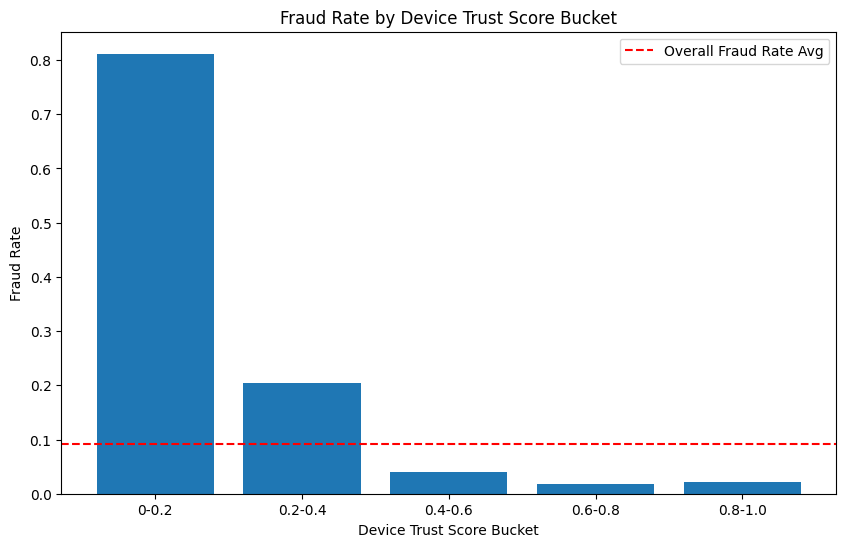

In [368]:
# examine device trust score and target variable relationship
df['device_trust_score_bucket'] = pd.cut(df['device_trust_score'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])
fraud_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean()
print("Fraud Rate by Device Trust Score Bucket:")
print(fraud_by_device_trust_score)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_device_trust_score)), fraud_by_device_trust_score.values)
plt.xticks(range(len(fraud_by_device_trust_score)), fraud_by_device_trust_score.index)
plt.xlabel('Device Trust Score Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Device Trust Score Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

In [369]:
# Based on the EDA, create a threshold-based features
df['night_time_transaction'] = ((df['hour_of_day'] >= 3) & (df['hour_of_day'] <= 8)).astype(int)
df['velocity_high'] = (df['txn_velocity_1h'] >= 3).astype(int)
df['amount_high'] = (df['amount_usd'] >= 500).astype(int)
df['ip_risk_high'] = (df['risk_score_internal'] >= 0.6).astype(int)
df['device_trust_low'] = (df['device_trust_score'] <= 0.4).astype(int)

print("New Features Created:")
print(df[['night_time_transaction', 'velocity_high', 'amount_high', 'ip_risk_high', 'device_trust_low']].describe())

New Features Created:
       night_time_transaction  velocity_high   amount_high  ip_risk_high  \
count            10780.000000   10780.000000  10780.000000  10780.000000   
mean                 0.262338       0.098516      0.126531      0.039054   
std                  0.439926       0.298025      0.332462      0.193732   
min                  0.000000       0.000000      0.000000      0.000000   
25%                  0.000000       0.000000      0.000000      0.000000   
50%                  0.000000       0.000000      0.000000      0.000000   
75%                  1.000000       0.000000      0.000000      0.000000   
max                  1.000000       1.000000      1.000000      1.000000   

       device_trust_low  
count      10780.000000  
mean           0.201391  
std            0.401058  
min            0.000000  
25%            0.000000  
50%            0.000000  
75%            0.000000  
max            1.000000  
